In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)

d:\Property Intelligence Platform


In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.decomposition import PCA

In [7]:
from src.data.ingestion import load_data

df= load_data("../data/feature_selection/gurgaon_properties_post_feature_selection_v2.csv")

Dataset loaded successfully.
Rows: 3553
Columns: 13


In [8]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,house,sector 92,0.85,4,4,3,Relatively New,1743.0,0,0,0,Low,Mid Floor
1,flat,sector 92,1.08,4,4,2,New Property,1891.0,1,0,0,Medium,High Floor
2,house,sector 33,8.00,4,4,3+,Old Property,7000.0,1,1,0,Medium,Low Floor
3,flat,sector 67a,1.60,3,3,2,New Property,1346.0,0,1,1,Medium,Mid Floor
4,house,sector 46,4.50,6,6,3+,Moderately Old,1845.0,0,1,1,Medium,Mid Floor


In [9]:
df['furnishing_type'].value_counts()

furnishing_type
0    2373
1     994
2     186
Name: count, dtype: int64

In [10]:
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished
df['furnishing_type'] = df['furnishing_type'].replace({0.0:'unfurnished',1.0:'semifurnished',2.0:'furnished'})

In [11]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,house,sector 92,0.85,4,4,3,Relatively New,1743.0,0,0,unfurnished,Low,Mid Floor
1,flat,sector 92,1.08,4,4,2,New Property,1891.0,1,0,unfurnished,Medium,High Floor
2,house,sector 33,8.00,4,4,3+,Old Property,7000.0,1,1,unfurnished,Medium,Low Floor
3,flat,sector 67a,1.60,3,3,2,New Property,1346.0,0,1,semifurnished,Medium,Mid Floor
4,house,sector 46,4.50,6,6,3+,Moderately Old,1845.0,0,1,semifurnished,Medium,Mid Floor


In [13]:
X = df.drop(columns=['price'])
y = df['price']

In [14]:
# Applying the log1p transformation to the target variable
y_transformed = np.log1p(y)

### Ordinal Encoding

In [163]:
X.columns

Index(['property_type', 'sector', 'bedRoom', 'bathroom', 'balcony',
       'agePossession', 'built_up_area', 'servant room', 'store room',
       'furnishing_type', 'luxury_category', 'floor_category'],
      dtype='object')

In [164]:
columns_to_encode =['property_type', 'sector','balcony','agePossession','furnishing_type','luxury_category','floor_category']
numeric_columns=['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']

In [15]:

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_columns = [
    'bedRoom',
    'bathroom',
    'built_up_area',
    'servant room',
    'store room'
]

columns_to_encode = [
   'property_type', 'sector','balcony','agePossession','furnishing_type','luxury_category','floor_category' 
]



numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


# -------------------------
# Categorical preprocessing
# -------------------------

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])


# -------------------------
# Column Transformer
# -------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_columns),
        ('cat', categorical_transformer, columns_to_encode)
    ],
    remainder='drop'
)

In [17]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [18]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores= cross_val_score(pipeline, X, y_transformed, cv=kfold,scoring='r2')
scores.mean(), scores.std()

(np.float64(0.7275660807962135), np.float64(0.04429691501989375))

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [20]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
y_pred = pipeline.predict(X_test)

In [23]:
y_pred = np.expm1(y_pred)

In [24]:
mean_absolute_error(np.expm1(y_test), y_pred)

1.0170127206533413

In [26]:
def scorer(model_name,model):

    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output
    

In [27]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,ExtraTreesRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor


In [28]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [29]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [30]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [31]:
model_df.sort_values(['mae'])

,name,r2,mae
10,xgboost,0.890403,0.546345
5,random forest,0.880203,0.559837
6,extra trees,0.865421,0.592373
7,gradient boosting,0.872993,0.618198
9,mlp,0.803346,0.735337
4,decision tree,0.779108,0.758847
8,adaboost,0.757395,0.801835
1,svr,0.751915,0.844474
2,ridge,0.727570,1.016793
0,linear_reg,0.727566,1.017013


### One Hot Encoding

In [ ]:
numeric_columns = [
    'bedRoom',
    'bathroom',
    'built_up_area',
    'servant room',
    'store room'
]

ordinal_columns = [
    'property_type',
    'balcony',
    'luxury_category',
    'floor_category'
]

onehot_columns = [
    'sector',
    'agePossession',
    'furnishing_type'
]



numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])



ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])


onehot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        drop='first',
        handle_unknown='ignore'
    ))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_columns),
        ('ordinal', ordinal_transformer, ordinal_columns),
        ('onehot', onehot_transformer, onehot_columns)
    ],
    remainder='drop'
)

In [ ]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
scores.mean(), scores.std()

(np.float64(0.849670968551903), np.float64(0.02718670934622466))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [ ]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred = pipeline.predict(X_test)

In [ ]:
y_pred = np.expm1(y_pred)  # Inverse transformation to get predictions in original scale

In [ ]:
mean_absolute_error(np.expm1(y_test),y_pred)

0.696389286961578

In [ ]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output

In [ ]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [ ]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Foun

In [ ]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])
model_df.sort_values(['mae'])

,name,r2,mae
6,extra trees,0.881133,0.543271
10,xgboost,0.887408,0.557307
1,svr,0.880805,0.577519
9,mlp,0.869301,0.580238
5,random forest,0.869197,0.584561
7,gradient boosting,0.857959,0.652264
0,linear_reg,0.849671,0.696389
2,ridge,0.849995,0.697544
4,decision tree,0.787033,0.746460
8,adaboost,0.726691,0.881741


### OneHotEncoding With PCA

In [ ]:
# Creating a column transformer for preprocessing
# Creating a column transformer for preprocessing
columns_to_encode_2 =['property_type','balcony','furnishing_type','luxury_category','floor_category']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1 ), columns_to_encode_2),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'),['sector','agePossession'])
    ], 
    remainder='passthrough'
)

In [ ]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.95)),
    ('regressor', LinearRegression())
])

In [ ]:
pipeline.get_feature_names_out

<bound method Pipeline.get_feature_names_out of Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['bedRoom', 'bathroom',
                                                   'built_up_area',
                                                   'servant room',
                                                   'store room']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['property_type', 'balcony',
                                                   'furnishing_type',
                                                   'luxury_category',
                                               

In [ ]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
scores.mean(), scores.std()

(np.float64(0.7544267302547787), np.float64(0.04104519594032054))

In [ ]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
pipeline.named_steps['pca'].n_components_

np.int64(37)

In [ ]:
pipeline.named_steps['pca'].explained_variance_ratio_

array([0.34529229, 0.10679388, 0.09523881, 0.070239  , 0.06676628,
       0.05084821, 0.04568302, 0.03362801, 0.03016725, 0.0191312 ,
       0.01478556, 0.01060551, 0.00760745, 0.00417898, 0.00342906,
       0.00321369, 0.00305948, 0.00295771, 0.00257918, 0.00250864,
       0.00247156, 0.00240805, 0.0022599 , 0.00203595, 0.00201924,
       0.00199633, 0.00195092, 0.00185327, 0.00180303, 0.00170892,
       0.00168228, 0.00166829, 0.00165854, 0.00161501, 0.00160603,
       0.00157918, 0.00153289])

In [ ]:
X_pca = pipeline.named_steps['pca'].transform(
    pipeline.named_steps['preprocessor'].transform(X_train)
)

print(X_pca.shape)

(2842, 37)


In [ ]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('pca', PCA(n_components=0.95)),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output

In [ ]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [ ]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Foun

In [ ]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])
model_df.sort_values(['mae'])

,name,r2,mae
6,extra trees,0.838760,0.630108
10,xgboost,0.833339,0.666240
5,random forest,0.824250,0.671250
9,mlp,0.827970,0.679825
7,gradient boosting,0.821452,0.718353
1,svr,0.825297,0.725500
8,adaboost,0.689459,0.921410
4,decision tree,0.619564,0.967163
2,ridge,0.754496,0.992762
0,linear_reg,0.754427,0.993921


### Target Encoding

In [ ]:
import category_encoders as ce

columns_to_encode_3 = ['property_type', 'balcony', 'furnishing_type', 'luxury_category', 'floor_category']

# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1), columns_to_encode_3),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'),['agePossession']),
        ('target_enc', ce.TargetEncoder(), ['sector'])
    ], 
    remainder='passthrough'
)

In [32]:
import category_encoders as ce


numeric_columns = [
    'bedRoom',
    'bathroom',
    'built_up_area',
    'servant room',
    'store room'
]

ordinal_columns = [
    'property_type',
    'balcony',
    'furnishing_type',
    'luxury_category',
    'floor_category'
]

onehot_columns = [
    'agePossession'
]

target_columns = [
    'sector'
]


# -------------------------
# Numeric pipeline
# -------------------------

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


# -------------------------
# Ordinal pipeline
# -------------------------

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])


# -------------------------
# One-Hot pipeline
# -------------------------

onehot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ))
])


# -------------------------
# Target Encoder
# -------------------------

target_encoder = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', ce.TargetEncoder())
])


# -------------------------
# Column Transformer
# -------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_columns),
        ('ordinal', ordinal_transformer, ordinal_columns),
        ('onehot', onehot_transformer, onehot_columns),
        ('target_enc', target_encoder, target_columns)
    ],
    remainder='drop'
)

In [ ]:
#!pip install category_encoders

In [33]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [34]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

In [35]:
scores.mean(),scores.std()

(np.float64(0.821408678662011), np.float64(0.023813136821741524))

In [36]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output
    

In [37]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [38]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [39]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])
model_df.sort_values(['mae'])

,name,r2,mae
6,extra trees,0.888998,0.516132
5,random forest,0.891886,0.525389
10,xgboost,0.892205,0.536362
7,gradient boosting,0.883047,0.551176
1,svr,0.860131,0.604461
9,mlp,0.847622,0.631402
8,adaboost,0.817259,0.697802
4,decision tree,0.801818,0.730199
0,linear_reg,0.821409,0.741690
2,ridge,0.821428,0.742082


### Hyperparameter Tuning

In [40]:
from sklearn.model_selection import GridSearchCV

In [41]:
param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [None, 10, 20],
    'regressor__max_samples':[0.1, 0.25, 0.5, 1.0],
    'regressor__max_features': [ 'log2', 'sqrt']
}

In [42]:
numeric_columns = [
    'bedRoom', 'bathroom', 'built_up_area',
    'servant room', 'store room'
]

ordinal_columns = [
    'property_type',
    'balcony',
    'furnishing_type',
    'luxury_category',
    'floor_category'
]

onehot_columns = ['agePossession']

target_columns = ['sector']


numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

onehot_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ))
])

target_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', ce.TargetEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_columns),
        ('ordinal', ordinal_transformer, ordinal_columns),
        ('onehot', onehot_transformer, onehot_columns),
        ('target', target_transformer, target_columns)
    ],
    remainder='drop'
)

In [44]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor())
])

In [45]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

In [46]:
search = GridSearchCV(pipeline, param_grid, cv=kfold, scoring='r2', n_jobs=-1, verbose=4)

In [47]:
search.fit(X, y_transformed)

Fitting 10 folds for each of 72 candidates, totalling 720 fits


,estimator,Pipeline(step...Regressor())])
,param_grid,"{'regressor__max_depth': [None, 10, ...], 'regressor__max_features': ['log2', 'sqrt'], 'regressor__max_samples': [0.1, 0.25, ...], 'regressor__n_estimators': [50, 100, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,4
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('ordinal', ...), ...]"


In [48]:
final_pipe = search.best_estimator_

In [49]:
search.best_params_

{'regressor__max_depth': 20,
 'regressor__max_features': 'sqrt',
 'regressor__max_samples': 1.0,
 'regressor__n_estimators': 200}

In [50]:
search.best_score_

np.float64(0.8882135590121895)

In [ ]:
! pip install optuna


Defaulting to user installation because normal site-packages is not writeable


In [51]:
import optuna

print(optuna.__version__)

4.9.0


In [52]:
import optuna
def objective(trial):

    model_name = trial.suggest_categorical(
        "model",
        [
            "RandomForest",
            "ExtraTrees",
            "GradientBoosting",
            "XGBoost",
            "SVR"
        ]
    )

    # ---------------- Random Forest ---------------- #

    if model_name == "RandomForest":

        params = {
            "n_estimators": trial.suggest_int("rf_n_estimators",100,300),
            "max_depth": trial.suggest_int("rf_max_depth",5,30),
            "min_samples_split": trial.suggest_int("rf_min_samples_split",2,10),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]),
            "bootstrap": trial.suggest_categorical("bootstrap",[True, False]),
            "random_state":42,
            "n_jobs":1
        }

        model = RandomForestRegressor(**params)

    # ---------------- Extra Trees ---------------- #

    elif model_name == "ExtraTrees":

        params = {
            "n_estimators": trial.suggest_int("et_n_estimators",50,200),
            "max_depth": trial.suggest_int("et_max_depth",5,30),
            "min_samples_split": trial.suggest_int("et_min_samples_split",2,10),
            "random_state":42,
            "n_jobs":1
        }

        model = ExtraTreesRegressor(**params)

    # ---------------- Gradient Boosting ---------------- #

    elif model_name == "GradientBoosting":

        params = {
            "n_estimators": trial.suggest_int("gb_n_estimators",50,400),
            "learning_rate": trial.suggest_float("gb_learning_rate",0.01,0.3),
            "max_depth": trial.suggest_int("gb_max_depth",2,8),
            "random_state":42
        }

        model = GradientBoostingRegressor(**params)

    # ---------------- XGBoost ---------------- #

    elif model_name == "XGBoost":

        params = {
            "n_estimators": trial.suggest_int("xgb_n_estimators",20,350),
            "learning_rate": trial.suggest_float("xgb_learning_rate",0.01,0.3),
            "max_depth": trial.suggest_int("max_depth", 3, 15),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
            "gamma": trial.suggest_float("gamma", 0, 10),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
            "colsample_bynode": trial.suggest_float("colsample_bynode", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 100, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 100, log=True),
            "max_delta_step": trial.suggest_int("max_delta_step", 0, 10),
            "random_state":42,
            "n_jobs":1
        }

        model = XGBRegressor(**params)

    # ---------------- SVR ---------------- #

    else:

        params = {
            "C": trial.suggest_float("svr_C",0.1,100,log=True),
            "gamma": trial.suggest_categorical("svr_gamma",["scale","auto"]),
            "kernel": trial.suggest_categorical("svr_kernel",["rbf","linear"])
        }

        model = SVR(**params)

    # ---------------- Pipeline ---------------- #

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=1
    ).mean()

    return score

In [53]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)   # Bayesian Optimization
)

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True,
    n_jobs=-1
)

[I 2026-08-09 17:51:10,782] A new study created in memory with name: no-name-f1d9c28a-33fe-4ba8-822d-8b533578956e


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-08-09 17:51:14,369] Trial 6 finished with value: 0.8247433018724928 and parameters: {'model': 'XGBoost', 'xgb_n_estimators': 52, 'xgb_learning_rate': 0.21284072469288529, 'max_depth': 10, 'min_child_weight': 13, 'gamma': 7.900243613806229, 'subsample': 0.9986567623947384, 'colsample_bytree': 0.5176079847120159, 'colsample_bylevel': 0.6035022572051854, 'colsample_bynode': 0.84234487508673, 'reg_alpha': 0.0031383089356034734, 'reg_lambda': 6.990654188225055e-07, 'max_delta_step': 8}. Best is trial 6 with value: 0.8247433018724928.
[I 2026-08-09 17:51:15,205] Trial 1 finished with value: 0.81476151520226 and parameters: {'model': 'SVR', 'svr_C': 0.11051062794128348, 'svr_gamma': 'scale', 'svr_kernel': 'linear'}. Best is trial 6 with value: 0.8247433018724928.
[I 2026-08-09 17:51:15,348] Trial 2 finished with value: 0.8550603197362614 and parameters: {'model': 'SVR', 'svr_C': 0.3957671657188503, 'svr_gamma': 'scale', 'svr_kernel': 'rbf'}. Best is trial 2 with value: 0.8550603197362

In [54]:
print("Best Score :", study.best_value)
print()
print("Best Parameters:")
print(study.best_params)

Best Score : 0.9044376158320926

Best Parameters:
{'model': 'GradientBoosting', 'gb_n_estimators': 235, 'gb_learning_rate': 0.1318510875418229, 'gb_max_depth': 6}


In [55]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

trials = study.trials_dataframe()
trials = trials.sort_values("value", ascending=False)
trials.head(10)

,number,value,datetime_start,datetime_complete,duration,params_bootstrap,params_colsample_bylevel,params_colsample_bynode,params_colsample_bytree,params_et_max_depth,params_et_min_samples_split,params_et_n_estimators,params_gamma,params_gb_learning_rate,params_gb_max_depth,params_gb_n_estimators,params_max_delta_step,params_max_depth,params_max_features,params_min_child_weight,params_min_samples_leaf,params_model,params_reg_alpha,params_reg_lambda,params_rf_max_depth,params_rf_min_samples_split,params_rf_n_estimators,params_subsample,params_svr_C,params_svr_gamma,params_svr_kernel,params_xgb_learning_rate,params_xgb_n_estimators,state
38,38,0.904438,2026-08-09 17:52:31.573629,2026-08-09 17:52:49.714910,0 days 00:00:18.141281,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.131851,6.0,235.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
64,64,0.904003,2026-08-09 17:56:28.337096,2026-08-09 17:56:42.206468,0 days 00:00:13.869372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.101019,6.0,208.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
94,94,0.903715,2026-08-09 17:58:28.103137,2026-08-09 17:58:50.024835,0 days 00:00:21.921698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.115081,6.0,322.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
37,37,0.903701,2026-08-09 17:52:30.347228,2026-08-09 17:52:46.996584,0 days 00:00:16.649356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.144956,6.0,220.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
99,99,0.903685,2026-08-09 17:58:42.593542,2026-08-09 17:58:54.583657,0 days 00:00:11.990115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100195,6.0,210.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
95,95,0.903588,2026-08-09 17:58:30.454164,2026-08-09 17:58:52.179768,0 days 00:00:21.725604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.104049,6.0,324.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
51,51,0.903517,2026-08-09 17:54:24.045903,2026-08-09 17:54:34.583330,0 days 00:00:10.537427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.182288,5.0,182.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
22,22,0.903430,2026-08-09 17:51:41.440320,2026-08-09 17:52:06.947803,0 days 00:00:25.507483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.141785,6.0,245.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
98,98,0.903171,2026-08-09 17:58:34.443854,2026-08-09 17:58:54.375930,0 days 00:00:19.932076,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.148190,6.0,322.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
76,76,0.902956,2026-08-09 17:57:46.262665,2026-08-09 17:58:04.122393,0 days 00:00:17.859728,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.188485,5.0,312.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE


In [56]:
study.trials_dataframe()['params_model'].value_counts()

params_model
GradientBoosting    59
SVR                 13
RandomForest        13
ExtraTrees           8
XGBoost              7
Name: count, dtype: int64

In [57]:
def create_model(trial):

    model_name = trial["params_model"]

    if model_name == "RandomForest":
        model = RandomForestRegressor(
            n_estimators=int(trial["params_rf_n_estimators"]),
            max_depth=int(trial["params_rf_max_depth"]),
            min_samples_split=int(trial["params_rf_min_samples_split"]),
            min_samples_leaf=int(trial["params_min_samples_leaf"]),
            max_features=trial["params_max_features"],
            bootstrap=trial["params_bootstrap"],
            random_state=42,
            n_jobs=1
        )

    elif model_name == "ExtraTrees":
        model = ExtraTreesRegressor(
            n_estimators=int(trial["params_et_n_estimators"]),
            max_depth=int(trial["params_et_max_depth"]),
            min_samples_split=int(trial["params_et_min_samples_split"]),
            random_state=42,
            n_jobs=1
        )

    elif model_name == "GradientBoosting":
        model = GradientBoostingRegressor(
            n_estimators=int(trial["params_gb_n_estimators"]),
            learning_rate=trial["params_gb_learning_rate"],
            max_depth=int(trial["params_gb_max_depth"]),
            random_state=42
        )

    elif model_name == "XGBoost":
        model = XGBRegressor(
            n_estimators=int(trial["params_xgb_n_estimators"]),
            learning_rate=trial["params_xgb_learning_rate"],
            max_depth=int(trial["params_max_depth"]),
            min_child_weight=int(trial["params_min_child_weight"]),
            gamma=trial["params_gamma"],
            subsample=trial["params_subsample"],
            colsample_bytree=trial["params_colsample_bytree"],
            colsample_bylevel=trial["params_colsample_bylevel"],
            colsample_bynode=trial["params_colsample_bynode"],
            reg_alpha=trial["params_reg_alpha"],
            reg_lambda=trial["params_reg_lambda"],
            max_delta_step=int(trial["params_max_delta_step"]),
            random_state=42,
            n_jobs=1
        )

    else:
        model = SVR(
            C=trial["params_svr_C"],
            gamma=trial["params_svr_gamma"],
            kernel=trial["params_svr_kernel"]
        )

    return model

In [58]:
from sklearn.metrics import r2_score, mean_absolute_error

def evaluate_model(model):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    return {
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred),
        "Train MAE": mean_absolute_error(np.expm1(y_train), np.expm1(train_pred)),
        "Test MAE": mean_absolute_error(np.expm1(y_test), np.expm1(test_pred))
    }

In [59]:
top5 = trials.head(20).copy()
results = []

for i in range(top5.shape[0]):

    trial = top5.iloc[i]

    model = create_model(trial)

    scores = evaluate_model(model)

    scores["CV R2"] = trial["value"]
    scores["Model"] = trial["params_model"]

    results.append(scores)

results_df = pd.DataFrame(results)

results_df

,Train R2,Test R2,Train MAE,Test MAE,CV R2,Model
0,0.994011,0.860594,0.110547,0.522307,0.904438,GradientBoosting
1,0.989009,0.866245,0.153144,0.520816,0.904003,GradientBoosting
2,0.995885,0.861758,0.091372,0.523565,0.903715,GradientBoosting
3,0.994592,0.867498,0.102496,0.528247,0.903701,GradientBoosting
4,0.988131,0.869367,0.158173,0.510158,0.903685,GradientBoosting
5,0.994553,0.865814,0.103195,0.529613,0.903588,GradientBoosting
6,0.987161,0.870695,0.165333,0.528007,0.903517,GradientBoosting
7,0.995147,0.869237,0.098027,0.509761,0.903430,GradientBoosting
8,0.997631,0.862144,0.066378,0.520159,0.903171,GradientBoosting
9,0.994553,0.867273,0.103137,0.526354,0.902956,GradientBoosting


In [60]:
best_trial = top5.iloc[10]

best_trial

number                                                 53
value                                            0.902915
datetime_start                 2026-08-09 17:54:37.063132
datetime_complete              2026-08-09 17:54:47.179007
duration                           0 days 00:00:10.115875
params_bootstrap                                      NaN
params_colsample_bylevel                              NaN
params_colsample_bynode                               NaN
params_colsample_bytree                               NaN
params_et_max_depth                                   NaN
params_et_min_samples_split                           NaN
params_et_n_estimators                                NaN
params_gamma                                          NaN
params_gb_learning_rate                          0.180751
params_gb_max_depth                                   5.0
params_gb_n_estimators                              186.0
params_max_delta_step                                 NaN
params_max_dep

In [61]:
final_model = create_model(best_trial)

In [62]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_model)
])

final_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
train_pred = final_pipeline.predict(X_train)
test_pred = final_pipeline.predict(X_test)

print("Train R2 :", r2_score(y_train, train_pred))
print("Test R2 :", r2_score(y_test, test_pred))

print("Train MAE :", mean_absolute_error(np.expm1(y_train), np.expm1(train_pred)))
print("Test MAE :", mean_absolute_error(np.expm1(y_test), np.expm1(test_pred)))

Train R2 : 0.9861520680479008
Test R2 : 0.8759657382701433
Train MAE : 0.17359052523521923
Test MAE : 0.5116267597405962


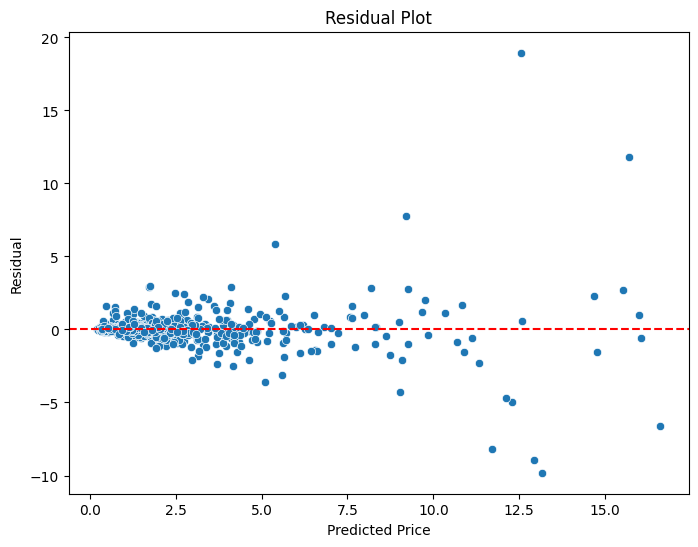

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predictions on test data
y_pred = final_pipeline.predict(X_test)

# Convert back from log scale
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

# Residuals
residuals = y_test_actual - y_pred_actual

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred_actual, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

### Exporting the model

In [65]:
import pickle
import os

os.makedirs("../artifacts", exist_ok=True)

with open("../artifacts/final_pipeline.pkl", "wb") as f:
    pickle.dump(final_pipeline, f)

print("Final pipeline saved successfully!")

Final pipeline saved successfully!


In [66]:
import pickle
import numpy as np

with open("../artifacts/final_pipeline.pkl", "rb") as f:
    loaded_pipeline = pickle.load(f)

original_pred = final_pipeline.predict(X_test)
loaded_pred = loaded_pipeline.predict(X_test)

print("Same predictions:",
      np.allclose(original_pred, loaded_pred))

Same predictions: True


In [67]:
def predict_price(input_df):
    """
    Predicts the price of a property given its features.

    Parameters:
    input_df (pd.DataFrame): A DataFrame containing the features of the property.

    Returns:
    float: The predicted price of the property.
    """
    # Load the saved pipeline
    with open("../artifacts/final_pipeline.pkl", "rb") as f:
        loaded_pipeline = pickle.load(f)

    # Make prediction
    log_price_pred = loaded_pipeline.predict(input_df)
    
    # Convert back from log scale
    price_pred = np.expm1(log_price_pred)

    return price_pred[0]

In [70]:
for i in X_test.columns:
    print(i, X_test[i].value_counts())

property_type property_type
flat     561
house    150
Name: count, dtype: int64
sector sector
sohna road                    31
sector 65                     23
sector 79                     20
sector 85                     20
sector 69                     20
sector 102                    19
sector 67                     19
sector 90                     18
sector 92                     17
sector 81                     16
sector 50                     15
sector 2                      15
sector 70                     14
sector 48                     14
sector 109                    14
sector 113                    13
sector 89                     13
sector 70a                    12
sector 108                    12
sector 43                     12
sector 104                    12
sector 107                    12
sector 83                     12
sector 61                     12
sector 49                     11
sector 33                     11
sector 86                     11
sector 95      

In [79]:
df.head(3)

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,house,sector 92,0.85,4,4,3,Relatively New,1743.0,0,0,unfurnished,Low,Mid Floor
1,flat,sector 92,1.08,4,4,2,New Property,1891.0,1,0,unfurnished,Medium,High Floor
2,house,sector 33,8.00,4,4,3+,Old Property,7000.0,1,1,unfurnished,Medium,Low Floor


In [ ]:
X_test.iloc[0]

property_type                flat
sector                  sector 79
bedRoom                         3
bathroom                        3
balcony                         3
agePossession      Relatively New
built_up_area              1165.0
servant room                    0
store room                      0
furnishing_type     semifurnished
luxury_category              High
floor_category         High Floor
Name: 299, dtype: object

In [84]:
import pandas as pd

def create_user_input():

    # Numerical inputs
    bedrooms = int(input("Bedrooms: "))
    bathrooms = int(input("Bathrooms: "))
    area = float(input("Built-up Area (sq.ft): "))

    servant_room = int(input("Servant Room? (0 = No, 1 = Yes): "))
    store_room = int(input("Store Room? (0 = No, 1 = Yes): "))


    # Property type
    while True:
        property_type = input(
            "Property Type (flat/house/villa): "
        ).lower().strip()

        if property_type in ["flat", "house", "villa"]:
            break
        else:
            print("❌ Invalid property type. Try again.")


    # Sector
    while True:
        sector = input("Sector Number: ").strip()

        if sector.isdigit():
            sector = "sector " + sector
            break
        else:
            print("❌ Enter only the sector number. Example: 92")


    # Balcony
    while True:
        balcony = input(
            "Balcony (0/1/2/3/3+): "
        ).strip()

        if balcony in ["0", "1", "2", "3", "3+"]:
            break
        else:
            print("❌ Invalid balcony. Choose 0, 1, 2, 3 or 3+.")


    # Age
    age_mapping = {
        "new": "New Property",
        "relatively new": "Relatively New",
        "moderately old": "Moderately Old",
        "old": "Old Property"
    }

    while True:
        age = input(
            "Age (new/relatively new/moderately old/old): "
        ).lower().strip()

        if age in age_mapping:
            age = age_mapping[age]
            break
        else:
            print("❌ Invalid age. Try again.")


    # Furnishing
    furnishing_mapping = {
        "furnished": "furnished",
        "semi-furnished": "semi-furnished",
        "unfurnished": "unfurnished"
    }

    while True:
        furnishing = input(
            "Furnishing (furnished/semi-furnished/unfurnished): "
        ).lower().strip()

        if furnishing in furnishing_mapping:
            furnishing = furnishing_mapping[furnishing]
            break
        else:
            print("❌ Invalid furnishing type. Try again.")


    # Luxury
    luxury_mapping = {
        "low": "Low",
        "medium": "Medium",
        "high": "High"
    }

    while True:
        luxury = input(
            "Luxury (low/medium/high): "
        ).lower().strip()

        if luxury in luxury_mapping:
            luxury = luxury_mapping[luxury]
            break
        else:
            print("❌ Invalid luxury category. Try again.")


    # Floor
    floor_mapping = {
        "low": "Low Floor",
        "mid": "Mid Floor",
        "high": "High Floor"
    }

    while True:
        floor = input(
            "Floor (low/mid/high): "
        ).lower().strip()

        if floor in floor_mapping:
            floor = floor_mapping[floor]
            break
        else:
            print("❌ Invalid floor category. Try again.")


    # Create dataframe
    user_input = {
        "bedRoom": bedrooms,
        "bathroom": bathrooms,
        "built_up_area": area,
        "servant room": servant_room,
        "store room": store_room,
        "property_type": property_type,
        "sector": sector,
        "balcony": balcony,
        "agePossession": age,
        "furnishing_type": furnishing,
        "luxury_category": luxury,
        "floor_category": floor
    }

    return pd.DataFrame([user_input])

In [87]:
applicant_df = create_user_input()

print("\nInput sent to model:")
display(applicant_df)

result = predict_price(applicant_df)

print("\nPredicted Price:", result)


Input sent to model:


,bedRoom,bathroom,built_up_area,servant room,store room,property_type,sector,balcony,agePossession,furnishing_type,luxury_category,floor_category
0,4,4,1890.0,1,0,flat,sector 92,2,New Property,unfurnished,Medium,High Floor



Predicted Price: 1.239910962849895


In [80]:
import pandas as pd

# -----------------------------
# Test Case 1
# -----------------------------
user_input_1 = {
    "bedRoom": 4,
    "bathroom": 4,
    "built_up_area": 1891.0,
    "servant room": 1,
    "store room": 0,
    "property_type": "flat",
    "sector": "sector 92",
    "balcony": 2,
    "agePossession": "New Property",
    "furnishing_type": "unfurnished",
    "luxury_category": "Medium",
    "floor_category": "High Floor"
}

applicant_df_1 = pd.DataFrame([user_input_1])

result_1 = predict_price(applicant_df_1)

print("Test Case 1 Predicted Price:", result_1)


# -----------------------------
# Test Case 2
# -----------------------------
user_input_2 = {
    "bedRoom": 4,
    "bathroom": 4,
    "built_up_area": 7000.0,
    "servant room": 1,
    "store room": 1,
    "property_type": "house",
    "sector": "sector 33",
    "balcony": "3+",
    "agePossession": "Old Property",
    "furnishing_type": "unfurnished",
    "luxury_category": "Medium",
    "floor_category": "Low Floor"
}

applicant_df_2 = pd.DataFrame([user_input_2])

result_2 = predict_price(applicant_df_2)

print("Test Case 2 Predicted Price:", result_2)

Test Case 1 Predicted Price: 1.1444426627326494
Test Case 2 Predicted Price: 8.436566728545587


In [88]:
import sys

print(sys.executable)

c:\ProgramData\anaconda3\python.exe
